# 3. K-Fold Gene Stability Analysis

**Schemat:**
1. Podział train/test (holdout) — test nie jest dotykany podczas selekcji genów
2. 10-fold CV **tylko na zbiorze treningowym** → selekcja stabilnych genów przez SHAP
3. Walidacja na holdout test — tylko AUC, dla różnych rozmiarów top-K genów

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
from collections import Counter, defaultdict
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
    WithinGroupVarianceReductor, AnovaFdrReductor,
)

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

# ── hyperparameters ──────────────────────────────────────────────
N_SPLITS            = 10
TOP_K               = 100    # top-K genów per fold liczonych do fold_count
TEST_SIZE           = 0.2    # holdout test
ANOVA_PERCENTILE    = 50
MEAN_PERCENTILE     = 10
WITHIN_GROUP_VAR_P  = 70
ANOVA_FDR_THRESHOLD = 0.1

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  


In [2]:
ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
sex_numeric = ds.sex.map({"F": 0, "M": 1})

print("Class mapping:")
for cls in le.classes_:
    print(f"  {cls} -> {le.transform([cls])[0]}")
print("\nClass distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
  Asymptomatic controls -> 0
  Pancreatic cancer -> 1

Class distribution:
0    459
1    124
Name: count, dtype: int64


In [3]:
# ── 1. Holdout train/test split ──────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = ds.get_train_test_valid_split(
    ds.X, y_encoded, test_size=TEST_SIZE, valid_size=0, return_valid=False
)

print(f"\nHoldout split:")
print(f"  Train: {len(X_train_raw)}  (cancer={y_train.sum()}, ctrl={(y_train==0).sum()})")
print(f"  Test:  {len(X_test_raw)}   (cancer={y_test.sum()},  ctrl={(y_test==0).sum()})")

# ── 2. K-Fold tylko na zbiorze treningowym ───────────────────────
folds = ds.get_stratified_kfold(X_train_raw, y_train, n_splits=N_SPLITS, random_state=2137)
print(f"\nK-Fold splits within train set: {len(folds)}")

[INFO] 7 samples with unique strata added to train set

Holdout split:
  Train: 467  (cancer=100, ctrl=367)
  Test:  116   (cancer=24,  ctrl=92)
[INFO] Generated 10 folds. Remainder (7) added to training set in each fold.

K-Fold splits within train set: 10


## Main loop — train + SHAP per fold

In [4]:
def build_pipeline():
    return Pipeline([
        ('ConstantExpressionReductor', ConstantExpressionReductor()),
        ('AnovaFDRReductor',           AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
        ('AnovaReductor',              AnovaReductor(percentile=ANOVA_PERCENTILE)),
        ('WithinGroupVarianceReductor',WithinGroupVarianceReductor(WITHIN_GROUP_VAR_P)),
        ('MeanExpressionReductor',     MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
        ('AgeBiasReductor',            CovariatesBiasReductor(covariate=ds.age)),
        ('SexBiasReductor',            CovariatesBiasReductor(covariate=sex_numeric)),
        ('scaler',                     StandardScaler()),
    ])

def snr(shap_matrix):
    """|mean(SHAP)| / std(SHAP) per gene."""
    eps = 1e-10
    return np.abs(shap_matrix.mean(axis=0)) / (shap_matrix.std(axis=0) + eps)

def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)


gene_scores_per_fold = defaultdict(list)

for fold_idx, (tr_idx, va_idx) in enumerate(folds):
    print(f"FOLD {fold_idx + 1}/{N_SPLITS}  train={len(tr_idx)}  val={len(va_idx)}")

    X_tr_raw = X_train_raw.iloc[tr_idx]
    X_va_raw = X_train_raw.iloc[va_idx]
    y_tr     = y_train.iloc[tr_idx]
    y_va     = y_train.iloc[va_idx]

    pipe  = build_pipeline()
    X_tr  = pipe.fit_transform(X_tr_raw, y_tr)
    X_va  = pipe.transform(X_va_raw)
    feature_names = list(pipe.named_steps['SexBiasReductor'].selected_genes_)
    print(f"  features: {len(feature_names)}")

    scale_pos_weight = Counter(y_tr)[0] / Counter(y_tr)[1]
    logreg = LogisticRegression(solver='saga', max_iter=15000, class_weight='balanced',
                                fit_intercept=True, l1_ratio=0.2)
    xgb    = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=500,
                           random_state=2137, verbosity=0)
    lgbm   = LGBMClassifier(n_estimators=200, learning_rate=0.05,
                            random_state=42, verbose=-1)

    for model in [logreg, xgb, lgbm]:
        model.fit(X_tr, y_tr)

    auc_lr   = roc_auc_score(y_va, logreg.predict_proba(X_va)[:, 1])
    auc_xgb  = roc_auc_score(y_va, xgb.predict_proba(X_va)[:, 1])
    auc_lgbm = roc_auc_score(y_va, lgbm.predict_proba(X_va)[:, 1])
    auc_arr  = np.array([auc_lr, auc_xgb, auc_lgbm])
    w        = auc_arr / auc_arr.sum()
    print(f"  AUC  logreg={auc_lr:.4f}  xgb={auc_xgb:.4f}  lgbm={auc_lgbm:.4f}")

    # SHAP -- zachowujemy pelna macierz (probki x geny) do liczenia SNR
    sv_lr       = shap.LinearExplainer(logreg, X_tr).shap_values(X_va)
    sv_lgbm_raw = shap.TreeExplainer(lgbm).shap_values(X_va)
    sv_lgbm     = sv_lgbm_raw[1] if isinstance(sv_lgbm_raw, list) else sv_lgbm_raw
    sv_xgb      = shap.TreeExplainer(xgb).shap_values(X_va)

    # |mean(SHAP)| / std(SHAP)
    score_lr   = snr(sv_lr)
    score_lgbm = snr(sv_lgbm)
    score_xgb  = snr(sv_xgb)

    weighted_score = (
        minmax_norm(score_lr)   * w[0] +
        minmax_norm(score_xgb)  * w[1] +
        minmax_norm(score_lgbm) * w[2]
    )

    fold_gene_score = dict(zip(feature_names, weighted_score))
    for gene in feature_names:
        if gene not in gene_scores_per_fold:
            gene_scores_per_fold[gene] = [0.0] * fold_idx
    all_seen = set(gene_scores_per_fold.keys()) | set(feature_names)
    for gene in all_seen:
        gene_scores_per_fold[gene].append(fold_gene_score.get(gene, 0.0))

for gene in gene_scores_per_fold:
    while len(gene_scores_per_fold[gene]) < N_SPLITS:
        gene_scores_per_fold[gene].append(0.0)

lengths = set(len(v) for v in gene_scores_per_fold.values())
print(f"Done. Genes tracked: {len(gene_scores_per_fold)}, list lengths: {lengths}")


FOLD 1/10  train=421  val=46
data shape after ConstantExpressionReductor:  (421, 31637)
data shape after AnovaFdrReductor:  (421, 3654)
data shape after AnovaReductor:  (421, 1827)
data shape after WithinGroupVarianceReductor:  (421, 1279)
data shape after MeanExpressionReductor:  (421, 1151)
data shape after CovariatesBiasReductor:  (421, 1045)
data shape after CovariatesBiasReductor:  (421, 1042)
data shape after ConstantExpressionReductor:  (46, 31637)
data shape after AnovaFdrReductor:  (46, 3654)
data shape after AnovaReductor:  (46, 1827)
data shape after WithinGroupVarianceReductor:  (46, 1279)
data shape after MeanExpressionReductor:  (46, 1151)
data shape after CovariatesBiasReductor:  (46, 1045)
data shape after CovariatesBiasReductor:  (46, 1042)
  features: 1042
  AUC  logreg=0.7917  xgb=0.8556  lgbm=0.8417
FOLD 2/10  train=421  val=46
data shape after ConstantExpressionReductor:  (421, 31688)
data shape after AnovaFdrReductor:  (421, 3322)
data shape after AnovaReductor:  

## Aggregation across folds

In [5]:
# top-K set per fold
fold_topk_genes = []
for fold_idx in range(N_SPLITS):
    scores_this_fold = {
        gene: scores[fold_idx]
        for gene, scores in gene_scores_per_fold.items()
        if scores[fold_idx] > 0
    }
    topk = sorted(scores_this_fold, key=scores_this_fold.get, reverse=True)[:TOP_K]
    fold_topk_genes.append(set(topk))

# summary dataframe
records = []
for gene, scores in gene_scores_per_fold.items():
    s = np.array(scores)
    records.append({
        'gene':         gene,
        'fold_count':   sum(1 for fset in fold_topk_genes if gene in fset),
        'mean_score':   s.mean(),
        'median_score': np.median(s),
        'max_score':    s.max(),
        'nonzero_mean': s[s > 0].mean() if (s > 0).any() else 0.0,
    })

stability_df = (
    pd.DataFrame(records)
    .sort_values(['fold_count', 'mean_score'], ascending=[False, False])
    .reset_index(drop=True)
)
stability_df.index += 1
stability_df.index.name = 'rank'

print(f"Total unique genes seen across all folds: {len(stability_df)}")
print(f"\nTop 30 most stable genes:")
stability_df.head(30)

Total unique genes seen across all folds: 1836

Top 30 most stable genes:


,gene,fold_count,mean_score,median_score,max_score,nonzero_mean
rank,,,,,,
1,ENSG00000256667,8,0.211664,0.222459,0.363189,0.211664
2,ENSG00000085733,7,0.205872,0.215255,0.307778,0.205872
3,ENSG00000164292,6,0.208530,0.210813,0.331042,0.208530
4,ENSG00000103202,6,0.197735,0.195213,0.345208,0.197735
5,ENSG00000188290,6,0.173609,0.186869,0.273451,0.173609
6,ENSG00000142089,5,0.218060,0.183352,0.536858,0.218060
7,ENSG00000187699,5,0.173369,0.167076,0.272239,0.173369
8,ENSG00000183019,5,0.151671,0.194284,0.258794,0.189589
9,ENSG00000165929,4,0.209437,0.175056,0.504265,0.209437


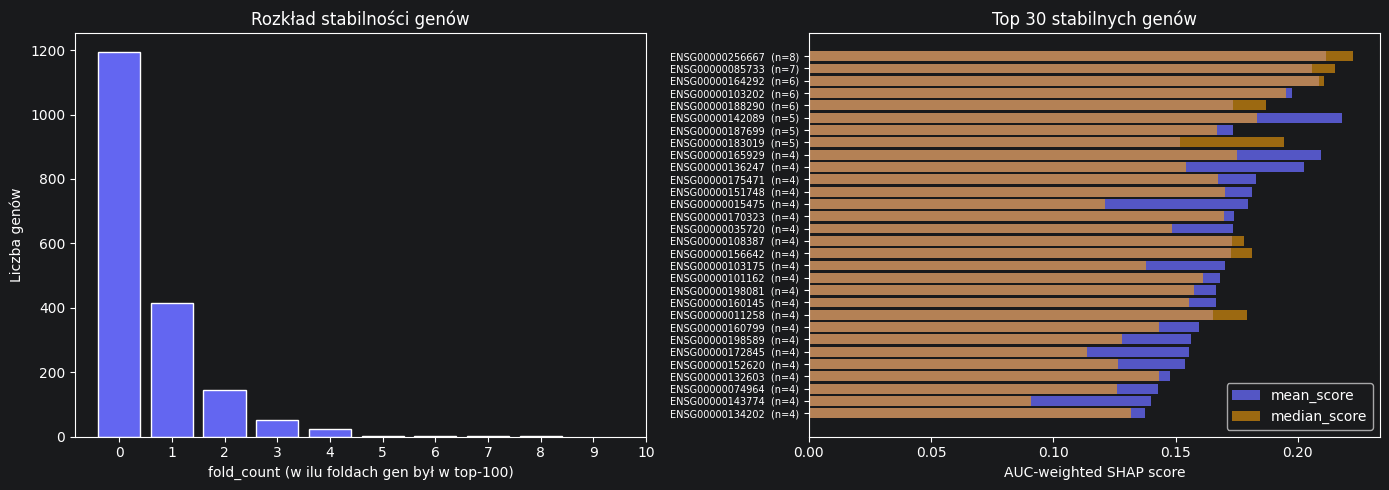

In [6]:
# rozkład fold_count
fc_counts = stability_df['fold_count'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fc_counts.index, fc_counts.values, color='#6366f1', edgecolor='white')
axes[0].set_xlabel('fold_count (w ilu foldach gen był w top-100)')
axes[0].set_ylabel('Liczba genów')
axes[0].set_title('Rozkład stabilności genów')
axes[0].set_xticks(range(0, N_SPLITS + 1))

top30 = stability_df.head(30)
y_pos = np.arange(len(top30))
axes[1].barh(y_pos, top30['mean_score'],   color='#6366f1', alpha=0.8, label='mean_score')
axes[1].barh(y_pos, top30['median_score'], color='#f59e0b', alpha=0.6, label='median_score')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    [f"{g}  (n={int(n)})" for g, n in zip(top30['gene'], top30['fold_count'])],
    fontsize=7
)
axes[1].invert_yaxis()
axes[1].set_xlabel('AUC-weighted SHAP score')
axes[1].set_title('Top 30 stabilnych genów')
axes[1].legend()
plt.tight_layout()
plt.show()

## Walidacja na holdout test

Trenujemy na pełnym zbiorze treningowym, testujemy na holdout — tylko AUC.
Sprawdzamy kilka progów top-N genów (np. top-5, 10, 20, 50) wybranych przez stability ranking.

In [7]:
# ── pipeline na pełnym train ─────────────────────────────────────
pipe_full = build_pipeline()
X_tr_full = pipe_full.fit_transform(X_train_raw, y_train)
X_te_full = pipe_full.transform(X_test_raw)
all_feature_names = list(pipe_full.named_steps['SexBiasReductor'].selected_genes_)

X_tr_df = pd.DataFrame(X_tr_full, columns=all_feature_names)
X_te_df = pd.DataFrame(X_te_full, columns=all_feature_names)

# ── walidacja dla różnych top-N ───────────────────────────────────
TOP_N_LIST = [5, 10, 15, 12, 20, 30, 40, 50]
val_results = []

for top_n in TOP_N_LIST:
    genes = stability_df.head(top_n)['gene'].tolist()
    # zostaw tylko geny które przeżyły selekcję na pełnym trainie
    genes_avail = [g for g in genes if g in all_feature_names]

    if len(genes_avail) < 2:
        print(f"top-{top_n}: za mało genów po selekcji ({len(genes_avail)}), pomijam")
        continue

    X_tr_n = X_tr_df[genes_avail].values
    X_te_n = X_te_df[genes_avail].values

    scale_pos_weight = Counter(y_train)[0] / Counter(y_train)[1]

    results_n = {}
    for name, model in [
        ('logreg', LogisticRegression(solver='saga', max_iter=15000,
                                      class_weight='balanced', fit_intercept=True)),
        ('xgb',    XGBClassifier(scale_pos_weight=scale_pos_weight,
                                 n_estimators=500, random_state=2137, verbosity=0)),
        ('lgbm',   LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                  random_state=42, verbose=-1)),
    ]:
        model.fit(X_tr_n, y_train)
        auc = roc_auc_score(y_test, model.predict_proba(X_te_n)[:, 1])
        results_n[f'auc_{name}'] = auc

    results_n['n_genes']      = len(genes_avail)
    results_n['n_requested']  = top_n
    val_results.append(results_n)
    print(f"top-{top_n:>2} ({len(genes_avail):>2} genów) | "
          f"logreg={results_n['auc_logreg']:.4f}  "
          f"xgb={results_n['auc_xgb']:.4f}  "
          f"lgbm={results_n['auc_lgbm']:.4f}")

val_df = pd.DataFrame(val_results).set_index('n_requested')
print(f"\nWyniki walidacji na holdout test (n={len(X_test_raw)}):")
val_df

data shape after ConstantExpressionReductor:  (467, 32261)
data shape after AnovaFdrReductor:  (467, 4326)
data shape after AnovaReductor:  (467, 2163)
data shape after WithinGroupVarianceReductor:  (467, 1514)
data shape after MeanExpressionReductor:  (467, 1362)
data shape after CovariatesBiasReductor:  (467, 1144)
data shape after CovariatesBiasReductor:  (467, 1133)
data shape after ConstantExpressionReductor:  (116, 32261)
data shape after AnovaFdrReductor:  (116, 4326)
data shape after AnovaReductor:  (116, 2163)
data shape after WithinGroupVarianceReductor:  (116, 1514)
data shape after MeanExpressionReductor:  (116, 1362)
data shape after CovariatesBiasReductor:  (116, 1144)
data shape after CovariatesBiasReductor:  (116, 1133)
top- 5 ( 5 genów) | logreg=0.7355  xgb=0.6839  lgbm=0.6925
top-10 (10 genów) | logreg=0.8130  xgb=0.7749  lgbm=0.8030
top-15 (15 genów) | logreg=0.7776  xgb=0.8392  lgbm=0.8591
top-12 (12 genów) | logreg=0.8075  xgb=0.7659  lgbm=0.7971
top-20 (20 genów) 

,auc_logreg,auc_xgb,auc_lgbm,n_genes
n_requested,,,,
5,0.735507,0.683877,0.692482,5
10,0.812953,0.774909,0.802989,10
15,0.777627,0.839221,0.859149,15
12,0.807518,0.765851,0.797101,12
20,0.789855,0.846014,0.884964,20
30,0.783514,0.782156,0.841486,30
40,0.748641,0.779891,0.803895,40
50,0.739130,0.795743,0.779438,50


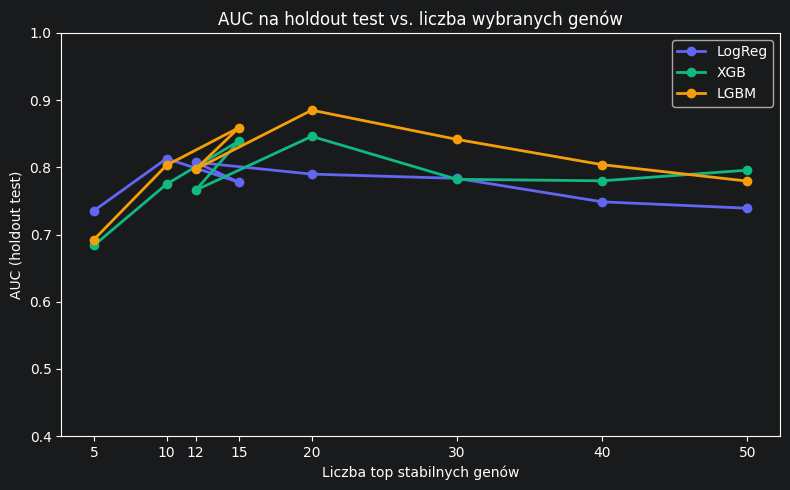

Zapisano: gene_stability_kfold.csv


In [8]:
# wykres AUC vs top-N
fig, ax = plt.subplots(figsize=(8, 5))
x = val_df.index
for col, label, color in [
    ('auc_logreg', 'LogReg', '#6366f1'),
    ('auc_xgb',   'XGB',    '#10b981'),
    ('auc_lgbm',  'LGBM',   '#f59e0b'),
]:
    ax.plot(x, val_df[col], marker='o', label=label, color=color, linewidth=2)

ax.set_xlabel('Liczba top stabilnych genów')
ax.set_ylabel('AUC (holdout test)')
ax.set_title('AUC na holdout test vs. liczba wybranych genów')
ax.legend()
ax.set_xticks(x)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

# zapis
stability_df.to_csv('gene_stability_kfold.csv', index=True)
print("Zapisano: gene_stability_kfold.csv")